In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../../processed")

last3_frames = []
for file in processed_dir.glob("*_last3_enriched.csv"):
    df = pd.read_csv(file)
    df["source_file"] = file.name
    last3_frames.append(df)

last3_df = pd.concat(last3_frames, ignore_index=True)

last3_df["Date"] = pd.to_datetime(last3_df["Date"], errors="coerce")
last3_df["point_diff"] = last3_df["home_last3_points"] - last3_df["away_last3_points"]
last3_df["home_win"] = (last3_df["result_match"] == "Home Win").astype(int)
last3_df["away_win"] = (last3_df["result_match"] == "Away Win").astype(int)
last3_df["draw"] = (last3_df["result_match"] == "Draw").astype(int)

last3_df.shape


# processed'deki last3 csvlerini teker teker alma


(3578, 32)

In [ ]:
print("Shape:", last3_df.shape)
print("Number of files:", last3_df["source_file"].nunique())

last3_df.head()


Shape: (3578, 32)
Number of files: 10


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,home_last3_points,away_last3_points,result_match,home_form,away_form,source_file,point_diff,home_win,away_win,draw
0,2020-09-18,Bayern Munich,Schalke 04,8,0,H,3.0,0.0,H,NaN,...,0,0,Home Win,bad,bad,bundesliga_2020_2021_last3_enriched.csv,0,1,0,0
1,2020-09-19,Ein Frankfurt,Bielefeld,1,1,D,0.0,0.0,D,NaN,...,0,0,Draw,bad,bad,bundesliga_2020_2021_last3_enriched.csv,0,0,0,1
2,2020-09-19,FC Koln,Hoffenheim,2,3,A,1.0,2.0,A,NaN,...,0,0,Away Win,bad,bad,bundesliga_2020_2021_last3_enriched.csv,0,0,1,0
3,2020-09-19,Stuttgart,Freiburg,2,3,A,0.0,2.0,A,NaN,...,0,0,Away Win,bad,bad,bundesliga_2020_2021_last3_enriched.csv,0,0,1,0
4,2020-09-19,Union Berlin,Augsburg,1,3,A,0.0,1.0,A,NaN,...,0,0,Away Win,bad,bad,bundesliga_2020_2021_last3_enriched.csv,0,0,1,0


In [6]:
last3_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3578 entries, 0 to 3577
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               3578 non-null   datetime64[ns]
 1   HomeTeam           3578 non-null   object        
 2   AwayTeam           3578 non-null   object        
 3   FTHG               3578 non-null   int64         
 4   FTAG               3578 non-null   int64         
 5   FTR                3578 non-null   object        
 6   HTHG               3577 non-null   float64       
 7   HTAG               3577 non-null   float64       
 8   HTR                3577 non-null   object        
 9   Referee            760 non-null    object        
 10  HS                 3577 non-null   float64       
 11  AS                 3577 non-null   float64       
 12  HST                3577 non-null   float64       
 13  AST                3577 non-null   float64       
 14  HF      

In [7]:
last3_df.isna().sum().sort_values(ascending=False)
# boş değer kontrolü


Referee              2818
HTHG                    1
AST                     1
HTAG                    1
AS                      1
HS                      1
HTR                     1
HST                     1
HF                      1
AF                      1
AR                      1
HR                      1
AY                      1
HY                      1
AC                      1
HC                      1
FTHG                    0
AwayTeam                0
Date                    0
HomeTeam                0
FTR                     0
FTAG                    0
home_last3_points       0
away_last3_points       0
result_match            0
home_form               0
away_form               0
source_file             0
point_diff              0
home_win                0
away_win                0
draw                    0
dtype: int64

In [8]:
last3_df[["home_last3_points", "away_last3_points", "point_diff"]].describe()


,home_last3_points,away_last3_points,point_diff
count,3578.000000,3578.000000,3578.000000
mean,3.823644,3.961710,-0.138066
std,2.505444,2.532857,3.283791
min,0.000000,0.000000,-9.000000
25%,2.000000,2.000000,-2.000000
50%,4.000000,4.000000,0.000000
75%,6.000000,6.000000,2.000000
max,9.000000,9.000000,9.000000


In [9]:
print("Home form:")
print(last3_df["home_form"].value_counts())

print("\nAway form:")
print(last3_df["away_form"].value_counts())
# ev sahibi, deplasmana göre form dağılımları


Home form:
home_form
bad       1677
medium    1312
good       589
Name: count, dtype: int64

Away form:
away_form
bad       1599
medium    1324
good       655
Name: count, dtype: int64


In [10]:
last3_df["result_match"].value_counts(normalize=True).round(3)
# maç sonuçlarının dağılımı 


result_match
Home Win    0.409
Away Win    0.339
Draw        0.252
Name: proportion, dtype: float64

In [11]:
form_result_counts = (
    last3_df
    .groupby(["home_form", "away_form", "result_match"])
    .size()
    .reset_index(name="match_count"))

pair_totals = (
    last3_df
    .groupby(["home_form", "away_form"])
    .size()
    .reset_index(name="total_matches"))

result_by_form_pair = pd.merge(
    form_result_counts,
    pair_totals,
    on=["home_form", "away_form"],
    how="left")

result_by_form_pair["result_rate"] = (
    result_by_form_pair["match_count"] / result_by_form_pair["total_matches"])

result_by_form_pair = result_by_form_pair.round(3)

result_by_form_pair
# son 3 maça göre form durumları eşleşmesi

,home_form,away_form,result_match,match_count,total_matches,result_rate
0,bad,bad,Away Win,287,827,0.347
1,bad,bad,Draw,204,827,0.247
2,bad,bad,Home Win,336,827,0.406
3,bad,good,Away Win,142,273,0.520
4,bad,good,Draw,68,273,0.249
5,bad,good,Home Win,63,273,0.231
6,bad,medium,Away Win,233,577,0.404
7,bad,medium,Draw,153,577,0.265
8,bad,medium,Home Win,191,577,0.331
9,good,bad,Away Win,39,210,0.186


In [12]:
last3_df["point_diff_interval"] = pd.cut(
    last3_df["point_diff"],
    bins=[-10, -4, -1, 1, 4, 10],
    labels=["<= -4", "-3 to -1", "0 to 1", "2 to 4", "> 4"],
    include_lowest=True
)

last3_df[["home_last3_points", "away_last3_points", "point_diff", "point_diff_interval"]].head()
# takımların son 3 maçtaki form grafiğini aralıklara bölme


,home_last3_points,away_last3_points,point_diff,point_diff_interval
0,0,0,0,0 to 1
1,0,0,0,0 to 1
2,0,0,0,0 to 1
3,0,0,0,0 to 1
4,0,0,0,0 to 1


In [13]:
point_diff_effect = (
    last3_df.groupby("point_diff_interval", observed=False).agg(
    matches=("result_match", "size"),
    home_win_rate=("result_match", lambda x: (x == "Home Win").mean()),
    away_win_rate=("result_match", lambda x: (x == "Away Win").mean()),
    draw_rate=("result_match", lambda x: (x == "Draw").mean())).round(3))
point_diff_effect
#last 3 matches'daki puan farklarına göre home win draw away win oranları

,matches,home_win_rate,away_win_rate,draw_rate
point_diff_interval,,,,
<= -4,567,0.266,0.492,0.242
-3 to -1,963,0.349,0.377,0.274
0 to 1,921,0.426,0.327,0.248
2 to 4,857,0.496,0.260,0.244
> 4,270,0.593,0.170,0.237


In [14]:
home_form_summary = (last3_df.groupby("home_form").agg(
        matches=("result_match", "size"),
        home_win_rate=("result_match", lambda x: (x == "Home Win").mean()),
        avg_point_diff=("point_diff", "mean")).round(3))
home_form_summary
#ev sahibi takımın form durumuna göre home win rate'leri

,matches,home_win_rate,avg_point_diff
home_form,,,
bad,1677,0.352,-2.001
good,589,0.521,3.396
medium,1312,0.432,0.657


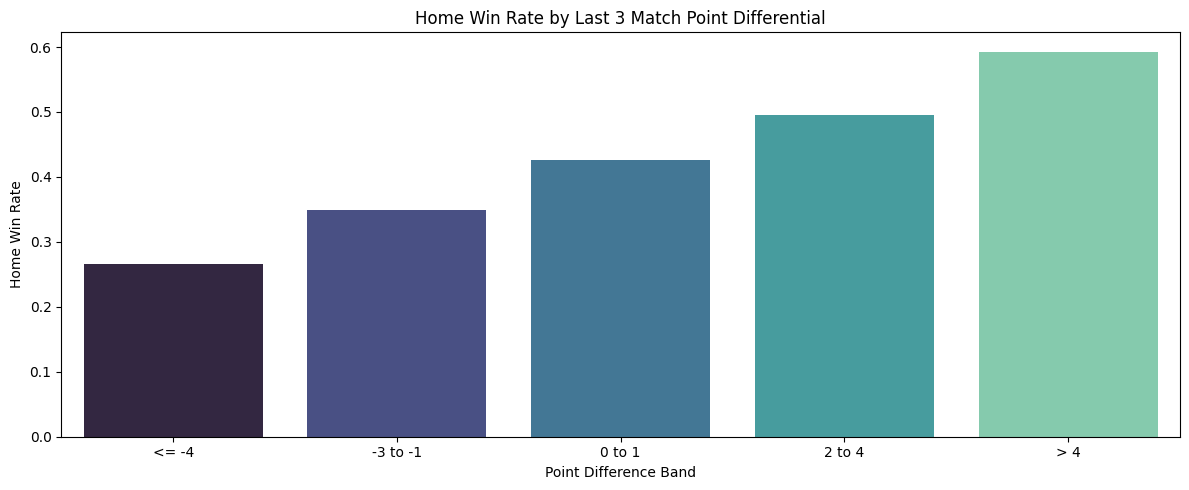

In [15]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=point_diff_effect.reset_index(),
    x="point_diff_interval",
    y="home_win_rate",
    hue="point_diff_interval",
    palette="mako",
    legend=False
)

plt.title("Home Win Rate by Last 3 Match Point Differential")
plt.xlabel("Point Difference Band")
plt.ylabel("Home Win Rate")
plt.tight_layout()
plt.show()


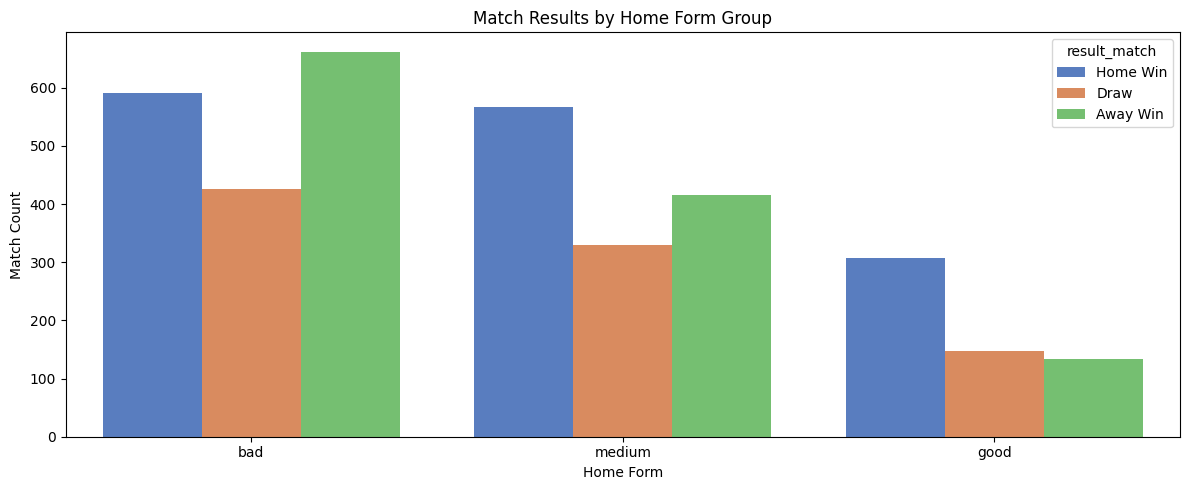

In [16]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=last3_df,
    x="home_form",
    hue="result_match",
    palette="muted")

plt.title("Match Results by Home Form Group")
plt.xlabel("Home Form")
plt.ylabel("Match Count")
plt.tight_layout()
plt.show()


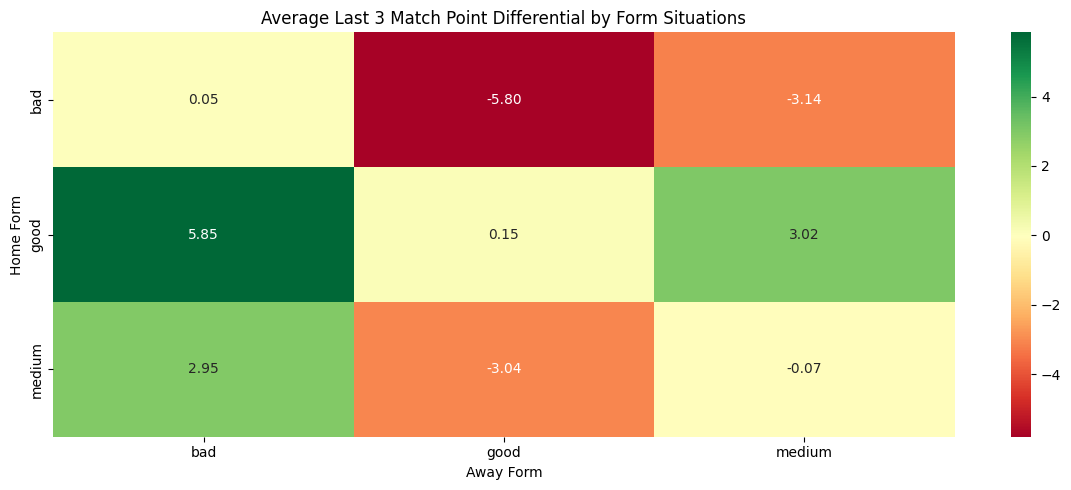

In [19]:
heatmap_data = (
    last3_df.pivot_table(
        index="home_form",
        columns="away_form",
        values="point_diff",
        aggfunc="mean").round(2))

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", center=0)

plt.title("Average Last 3 Match Point Differential by Form Situations")
plt.xlabel("Away Form")
plt.ylabel("Home Form")
plt.tight_layout()
plt.show()


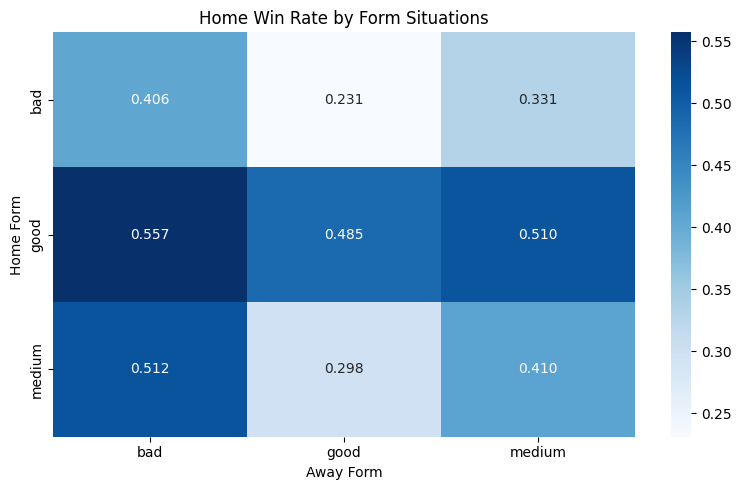

In [20]:
home_win_pivot = (
    last3_df.assign(home_win_flag=(last3_df["result_match"] == "Home Win").astype(int))
    .pivot_table(
        index="home_form",
        columns="away_form",
        values="home_win_flag",
        aggfunc="mean").round(3))

plt.figure(figsize=(8, 5))
sns.heatmap(home_win_pivot, annot=True, fmt=".3f", cmap="Blues")

plt.title("Home Win Rate by Form Situations")
plt.xlabel("Away Form")
plt.ylabel("Home Form")
plt.tight_layout()
plt.show()
